In [2]:
import pandas as pd
import numpy as np

# -------------------------------------------------
# Load Data
# -------------------------------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv")

y = df['Close'].values
x = np.arange(1, len(y) + 1)

n = len(y)

# -------------------------------------------------
# Choose Knot (example: middle point)
# -------------------------------------------------
c = int(n/2)

# Truncated quadratic term
def truncated_quad(x, c):
    return np.where(x > c, (x - c)**2, 0)

# -------------------------------------------------
# Design Matrix (Piecewise k=2)
# -------------------------------------------------
X = np.column_stack([
    np.ones(n),
    x,
    x**2,
    truncated_quad(x, c)
])

# -------------------------------------------------
# Estimate Coefficients
# -------------------------------------------------
beta = np.linalg.inv(X.T @ X) @ X.T @ y

# -------------------------------------------------
# Predicted Values
# -------------------------------------------------
y_pred = X @ beta

# -------------------------------------------------
# Compute SST, SSE, SSR, R²
# -------------------------------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_pred)**2)
SSR = SST - SSE
R_squared = SSR / SST

# -------------------------------------------------
# Print Output (Same Style As Your Notebook)
# -------------------------------------------------
print("\nPiecewise Polynomial Beta Values:")
print(beta)

print("\nFinal Predicted Equation:")
print(f"ŷ = {beta[0]:.6f} + {beta[1]:.6f}x + "
      f"{beta[2]:.6f}x² + {beta[3]:.6f}(x - {c})²_+")

print("\nSST =", SST)
print("SSE =", SSE)
print("SSR =", SSR)

print("\nR-squared =", R_squared)


Piecewise Polynomial Beta Values:
[ 2.37845855  0.06452578 -0.00371042  0.00710129]

Final Predicted Equation:
ŷ = 2.378459 + 0.064526x + -0.003710x² + 0.007101(x - 20)²_+

SST = 12.243639024390243
SSE = 6.1455372200790235
SSR = 6.098101804311219

R-squared = 0.49806285469241174


In [4]:
import pandas as pd
import numpy as np

# -------------------------------------------------
# Load Data
# -------------------------------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv")

y = df['Close'].values
x = np.arange(1, len(y) + 1)

n = len(y)

# -------------------------------------------------
# Choose Knot (middle point)
# -------------------------------------------------
c = int(n/2)

def truncated_quad(x, c):
    return np.where(x > c, (x - c)**2, 0)

# -------------------------------------------------
# Design Matrix
# -------------------------------------------------
X = np.column_stack([
    np.ones(n),
    x,
    x**2,
    truncated_quad(x, c)
])

p = X.shape[1]   # number of parameters (4)

# -------------------------------------------------
# Estimate Coefficients
# -------------------------------------------------
beta = np.linalg.inv(X.T @ X) @ X.T @ y
y_pred = X @ beta

# -------------------------------------------------
# Compute Sums of Squares
# -------------------------------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_pred)**2)
SSR = SST - SSE

# -------------------------------------------------
# Degrees of Freedom
# -------------------------------------------------
df_total = n - 1
df_reg = p - 1
df_res = n - p

# -------------------------------------------------
# Mean Squares
# -------------------------------------------------
MS_reg = SSR / df_reg
MS_res = SSE / df_res

F_stat = MS_reg / MS_res

# -------------------------------------------------
# Print ANOVA Table (Like Your Screenshot)
# -------------------------------------------------
print("\nANOVA TABLE - PIECEWISE (k=2)")
print("------------------------------------------------------------")
print(f"{'Source':<12}{'DF':<8}{'SS':<15}{'MS':<15}{'F':<10}")
print("------------------------------------------------------------")
print(f"{'Regression':<12}{df_reg:<8}{SSR:<15.6f}{MS_reg:<15.6f}{F_stat:<10.6f}")
print(f"{'Residual':<12}{df_res:<8}{SSE:<15.6f}{MS_res:<15.6f}")
print(f"{'Total':<12}{df_total:<8}{SST:<15.6f}")
print("------------------------------------------------------------")


ANOVA TABLE - PIECEWISE (k=2)
------------------------------------------------------------
Source      DF      SS             MS             F         
------------------------------------------------------------
Regression  3       6.098102       2.032701       12.238136 
Residual    37      6.145537       0.166096       
Total       40      12.243639      
------------------------------------------------------------


In [5]:
# -------------------------------------------------
# CHECK SIGNIFICANCE OF THE MODEL (Piecewise k=2)
# -------------------------------------------------

from scipy.stats import f

alpha_level = 0.05

# F-statistic already computed earlier:
# F_stat = MS_reg / MS_res

# p-value
p_value = 1 - f.cdf(F_stat, df_reg, df_res)

print("\nSignificance Test")
print("----------------------------")
print("F-statistic =", F_stat)
print("Degrees of Freedom =", df_reg, "and", df_res)
print("p-value =", p_value)
print("Significance level (alpha) =", alpha_level)

# Decision
if p_value < alpha_level:
    print("\nDecision: Reject H0")
    print("Conclusion: The piecewise quadratic model is statistically significant.")
else:
    print("\nDecision: Fail to Reject H0")
    print("Conclusion: The model is NOT statistically significant.")




Significance Test
----------------------------
F-statistic = 12.23813631905798
Degrees of Freedom = 3 and 37
p-value = 1.0379380920189085e-05
Significance level (alpha) = 0.05

Decision: Reject H0
Conclusion: The piecewise quadratic model is statistically significant.


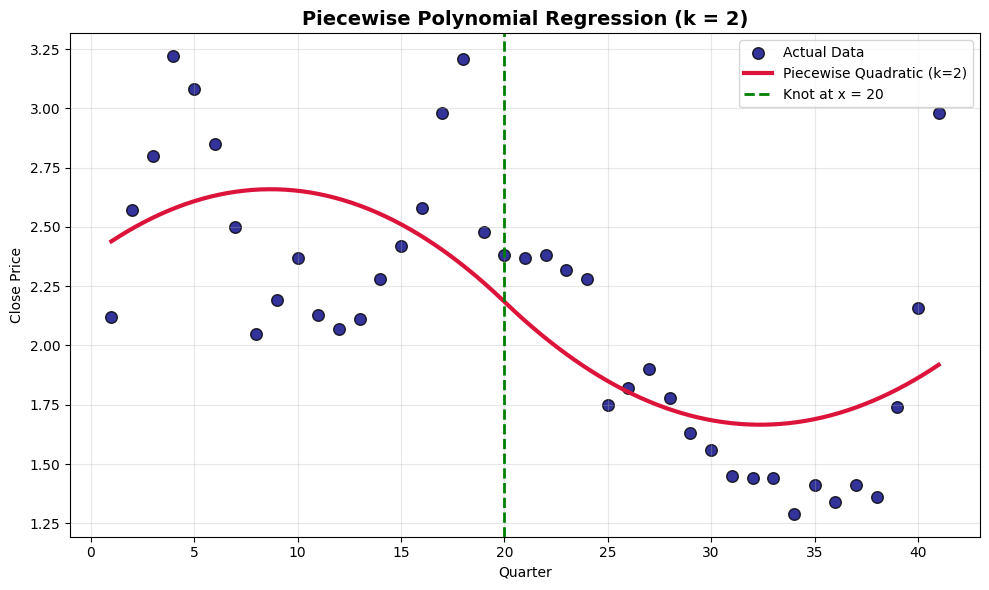

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Load Data
# -------------------------------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv")

y = df['Close'].values
x = np.arange(1, len(y) + 1)
n = len(y)

# -------------------------------------------------
# Choose Knot (middle point)
# -------------------------------------------------
c = int(n / 2)

def truncated_quad(x, c):
    return np.where(x > c, (x - c)**2, 0)

# -------------------------------------------------
# Design Matrix
# -------------------------------------------------
X = np.column_stack([
    np.ones(n),
    x,
    x**2,
    truncated_quad(x, c)
])

# -------------------------------------------------
# Estimate Coefficients
# -------------------------------------------------
beta = np.linalg.inv(X.T @ X) @ X.T @ y
y_pred = X @ beta

# -------------------------------------------------
# Smooth Curve for Plotting
# -------------------------------------------------
x_fine = np.linspace(min(x), max(x), 400)

X_fine = np.column_stack([
    np.ones(len(x_fine)),
    x_fine,
    x_fine**2,
    truncated_quad(x_fine, c)
])

y_fine = X_fine @ beta

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(10,6))

plt.scatter(x, y,
            color="navy",
            edgecolor="black",
            s=70,
            alpha=0.8,
            label="Actual Data")

plt.plot(x_fine, y_fine,
         color="crimson",
         linewidth=3,
         label="Piecewise Quadratic (k=2)")

# Show knot location
plt.axvline(x=c,
            color="green",
            linestyle="--",
            linewidth=2,
            label=f"Knot at x = {c}")

plt.title("Piecewise Polynomial Regression (k = 2)",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Quarter")
plt.ylabel("Close Price")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Piecewise Cubic Beta Values:
[ 3.02642878e+00 -1.92300152e-01  1.80631209e-02 -4.88488457e-04
  1.15312683e-03]

Final Predicted Equation:
ŷ = 3.026429 + -0.192300x + 0.018063x² + -0.000488x³ + 0.001153(x - 20)³_+

SST = 12.243639024390243
SSE = 3.5317643846525035
SSR = 8.71187463973774

R-squared = 0.7115429181130737


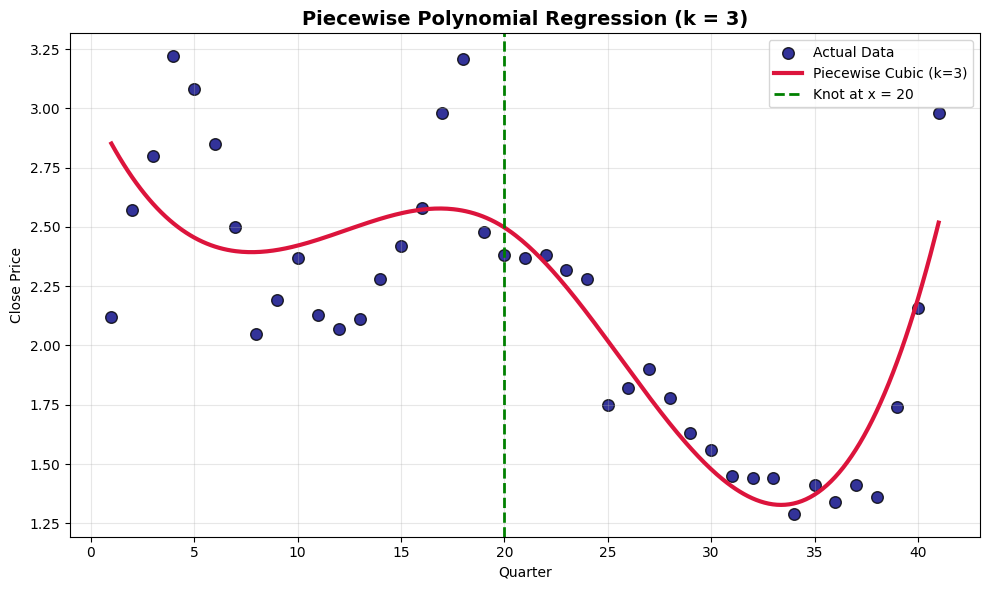

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Load Data
# -------------------------------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv")

y = df['Close'].values
x = np.arange(1, len(y) + 1)

n = len(y)

# -------------------------------------------------
# Choose Knot (middle point)
# -------------------------------------------------
c = int(n / 2)

def truncated_cubic(x, c):
    return np.where(x > c, (x - c)**3, 0)

# -------------------------------------------------
# Design Matrix (Piecewise Cubic)
# -------------------------------------------------
X = np.column_stack([
    np.ones(n),
    x,
    x**2,
    x**3,
    truncated_cubic(x, c)
])

p = X.shape[1]

# -------------------------------------------------
# Estimate Coefficients
# -------------------------------------------------
beta = np.linalg.inv(X.T @ X) @ X.T @ y
y_pred = X @ beta

# -------------------------------------------------
# Compute SST, SSE, SSR, R²
# -------------------------------------------------
SST = np.sum((y - np.mean(y))**2)
SSE = np.sum((y - y_pred)**2)
SSR = SST - SSE
R_squared = SSR / SST

# -------------------------------------------------
# Print Output
# -------------------------------------------------
print("\nPiecewise Cubic Beta Values:")
print(beta)

print("\nFinal Predicted Equation:")
print(f"ŷ = {beta[0]:.6f} + {beta[1]:.6f}x + "
      f"{beta[2]:.6f}x² + {beta[3]:.6f}x³ + "
      f"{beta[4]:.6f}(x - {c})³_+")

print("\nSST =", SST)
print("SSE =", SSE)
print("SSR =", SSR)
print("\nR-squared =", R_squared)

# -------------------------------------------------
# Plot
# -------------------------------------------------
x_fine = np.linspace(min(x), max(x), 400)

X_fine = np.column_stack([
    np.ones(len(x_fine)),
    x_fine,
    x_fine**2,
    x_fine**3,
    truncated_cubic(x_fine, c)
])

y_fine = X_fine @ beta

plt.figure(figsize=(10,6))

plt.scatter(x, y,
            color="navy",
            edgecolor="black",
            s=70,
            alpha=0.8,
            label="Actual Data")

plt.plot(x_fine, y_fine,
         color="crimson",
         linewidth=3,
         label="Piecewise Cubic (k=3)")

plt.axvline(x=c,
            color="green",
            linestyle="--",
            linewidth=2,
            label=f"Knot at x = {c}")

plt.title("Piecewise Polynomial Regression (k = 3)",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Quarter")
plt.ylabel("Close Price")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
# -------------------------------------------------
# ANOVA TABLE - PIECEWISE CUBIC (k = 3)
# -------------------------------------------------

# Degrees of Freedom
df_total = n - 1
df_reg = p - 1      # p = number of parameters
df_res = n - p

# Mean Squares
MS_reg = SSR / df_reg
MS_res = SSE / df_res

# F-statistic
F_stat = MS_reg / MS_res

# -------------------------------------------------
# Print ANOVA Table (Notebook Style)
# -------------------------------------------------

print("\nANOVA TABLE - PIECEWISE CUBIC (k=3)")
print("------------------------------------------------------------")
print(f"{'Source':<12}{'DF':<8}{'SS':<15}{'MS':<15}{'F':<10}")
print("------------------------------------------------------------")
print(f"{'Regression':<12}{df_reg:<8}{SSR:<15.6f}{MS_reg:<15.6f}{F_stat:<10.6f}")
print(f"{'Residual':<12}{df_res:<8}{SSE:<15.6f}{MS_res:<15.6f}")
print(f"{'Total':<12}{df_total:<8}{SST:<15.6f}")
print("------------------------------------------------------------")



ANOVA TABLE - PIECEWISE CUBIC (k=3)
------------------------------------------------------------
Source      DF      SS             MS             F         
------------------------------------------------------------
Regression  4       8.711875       2.177969       22.200482 
Residual    36      3.531764       0.098105       
Total       40      12.243639      
------------------------------------------------------------


In [9]:
# -------------------------------------------------
# CHECK SIGNIFICANCE OF PIECEWISE CUBIC MODEL (k = 3)
# -------------------------------------------------

from scipy.stats import f

alpha_level = 0.05

# p-value from F-distribution
p_value = 1 - f.cdf(F_stat, df_reg, df_res)

print("\nSignificance Test")
print("----------------------------")
print("F-statistic =", F_stat)
print("Degrees of Freedom =", df_reg, "and", df_res)
print("p-value =", p_value)
print("Significance level (alpha) =", alpha_level)

# Decision Rule
if p_value < alpha_level:
    print("\nDecision: Reject H0")
    print("Conclusion: The piecewise cubic model is statistically significant.")
else:
    print("\nDecision: Fail to Reject H0")
    print("Conclusion: The piecewise cubic model is NOT statistically significant.")



Significance Test
----------------------------
F-statistic = 22.200482030557158
Degrees of Freedom = 4 and 36
p-value = 2.6398869756860677e-09
Significance level (alpha) = 0.05

Decision: Reject H0
Conclusion: The piecewise cubic model is statistically significant.


In [15]:
import pandas as pd
import numpy as np

# -------------------------
# Load Data
# -------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv")

y = df['Close'].values
x = np.arange(len(y))   # IMPORTANT: 0 to n-1  (most common cause of mismatch)

n = len(y)

# -------------------------
# Function using np.polyfit
# -------------------------
def poly_metrics_np(x, y, degree):

    # Fit polynomial
    coeffs = np.polyfit(x, y, degree)

    # Predicted values
    y_hat = np.polyval(coeffs, x)

    # Manual sums
    y_mean = np.mean(y)

    SST = np.sum((y - y_mean)**2)
    SSE = np.sum((y - y_hat)**2)

    R2 = 1 - (SSE / SST)

    p = degree
    adj_R2 = 1 - ((1 - R2)*(n - 1)/(n - p - 1))

    RMSE = np.sqrt(SSE / n)
    MAPE = np.mean(np.abs((y - y_hat)/y)) * 100

    return RMSE, MAPE, R2, adj_R2


# k = 2
rmse2, mape2, r2_2, adj2 = poly_metrics_np(x, y, 2)

# k = 3
rmse3, mape3, r2_3, adj3 = poly_metrics_np(x, y, 3)

# -------------------------
# Print Table
# -------------------------
print("\nPolynomial Regression Results\n")

print(f"{'Metric':<12}{'Quadratic':<20}{'Cubic':<20}")
print("-"*55)

print(f"{'RMSE':<12}{rmse2:<20.6f}{rmse3:<20.6f}")
print(f"{'MAPE':<12}{mape2:<20.6f}{mape3:<20.6f}")
print(f"{'R^2':<12}{r2_2:<20.15f}{r2_3:<20.15f}")
print(f"{'Adj R^2':<12}{adj2:<20.15f}{adj3:<20.15f}")



Polynomial Regression Results

Metric      Quadratic           Cubic               
-------------------------------------------------------
RMSE        0.421018            0.373662            
MAPE        16.343197           14.170174           
R^2         0.406427234072900   0.532446029425855   
Adj R^2     0.375186562182000   0.494536248027951   


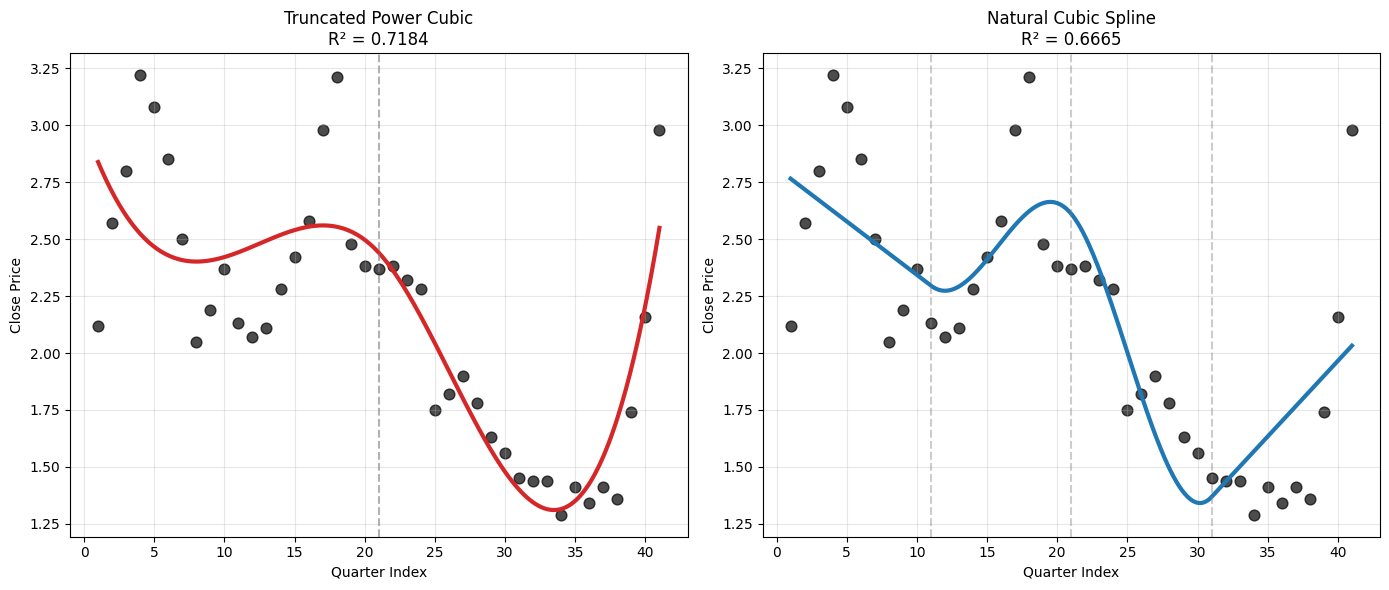

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import SplineTransformer
from sklearn.metrics import r2_score

# -------------------------------------------------
# Load Data
# -------------------------------------------------
df = pd.read_csv("/content/AEY Real(Charts Quarterly).csv")

y = df['Close'].values
x = np.arange(1, len(y) + 1).reshape(-1,1)

n = len(y)

# -------------------------------------------------
# 1️⃣ TRUNCATED POWER CUBIC (OLD METHOD)
# -------------------------------------------------

# Optimal knot using 50% quantile
knot = int(np.quantile(x, 0.5))

def truncated_cubic(x, c):
    return np.where(x > c, (x - c)**3, 0)

X_trunc = np.column_stack([
    np.ones(n),
    x.flatten(),
    x.flatten()**2,
    x.flatten()**3,
    truncated_cubic(x.flatten(), knot)
])

beta_trunc = np.linalg.inv(X_trunc.T @ X_trunc) @ X_trunc.T @ y
y_trunc = X_trunc @ beta_trunc
r2_trunc = r2_score(y, y_trunc)

# -------------------------------------------------
# 2️⃣ PROPER NATURAL CUBIC SPLINE
# -------------------------------------------------

# Choose 3 interior knots using quantiles (optimal)
knots = np.quantile(x, [0.25, 0.5, 0.75])

spline = SplineTransformer(
    degree=3,
    knots=knots.reshape(-1,1),
    extrapolation='linear'  # Natural spline behaviour
)

X_spline = spline.fit_transform(x)

model_spline = LinearRegression()
model_spline.fit(X_spline, y)

y_spline = model_spline.predict(X_spline)
r2_spline = r2_score(y, y_spline)

# -------------------------------------------------
# Smooth Curves for Plotting
# -------------------------------------------------

x_fine = np.linspace(min(x), max(x), 400).reshape(-1,1)

# Truncated smooth
X_trunc_fine = np.column_stack([
    np.ones(len(x_fine)),
    x_fine.flatten(),
    x_fine.flatten()**2,
    x_fine.flatten()**3,
    truncated_cubic(x_fine.flatten(), knot)
])
y_trunc_fine = X_trunc_fine @ beta_trunc

# Natural spline smooth
X_spline_fine = spline.transform(x_fine)
y_spline_fine = model_spline.predict(X_spline_fine)

# -------------------------------------------------
# 3️⃣ PROFESSIONAL SIDE-BY-SIDE PLOT
# -------------------------------------------------

plt.figure(figsize=(14,6))

# ----- Truncated Power Model -----
plt.subplot(1,2,1)
plt.scatter(x, y, color="black", s=60, alpha=0.7)
plt.plot(x_fine, y_trunc_fine, color="#d62728", linewidth=3)
plt.axvline(knot, color="gray", linestyle="--", alpha=0.6)
plt.title(f"Truncated Power Cubic\nR² = {r2_trunc:.4f}", fontsize=12)
plt.xlabel("Quarter Index")
plt.ylabel("Close Price")
plt.grid(alpha=0.3)

# ----- Natural Cubic Spline -----
plt.subplot(1,2,2)
plt.scatter(x, y, color="black", s=60, alpha=0.7)
plt.plot(x_fine, y_spline_fine, color="#1f77b4", linewidth=3)
for k in knots:
    plt.axvline(k, color="gray", linestyle="--", alpha=0.4)
plt.title(f"Natural Cubic Spline\nR² = {r2_spline:.4f}", fontsize=12)
plt.xlabel("Quarter Index")
plt.ylabel("Close Price")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
